# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [3]:
pip install shap


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     -------------------------------------- 456.1/456.1 kB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 78.6/78.6 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 28.1/28.1 MB 1.0 MB/s eta 0:00:00


In [1]:
import pandas as pd

# Load the data with the updated path
data_path = r"C:\Users\Beast\Desktop\forest\forestfires.csv"

# Load the data into a DataFrame
try:
    fires_dt = pd.read_csv(data_path, header=0, names=[
        'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area'
    ])
    fires_dt.info()
except FileNotFoundError:
    print("The dataset file is not found. Please make sure the path is correct.")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [2]:
X = fires_dt.drop('area', axis=1)  # Features
Y = fires_dt['area']  # Target


In [4]:
# 
feature_columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain'
]
target_column = 'area'

# 
X = fires_dt[feature_columns]  # 
y = fires_dt[target_column]    # 

# 
print("Feature Data Frame (X):")
print(X.head())
print("\nTarget Data (y):")
print(y.head())


Feature Data Frame (X):
   coord_x  coord_y month  day  ffmc   dmc     dc  isi  temp  rh  wind  rain
0        7        5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1        7        4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2        7        4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3        8        6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4        8        6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0

Target Data (y):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numerical and categorical features
numerical_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Create Preproc 1: scaling for numerical features and one-hot encoding for categorical features
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scaling numerical features
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encoding categorical features
    ]
)

print(preproc1)



ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(), ['month', 'day'])])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define numerical and categorical features
numerical_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Create Preproc 2: scaling numerical features, non-linear transformation for one or more variables, one-hot encoding for categorical features
preproc2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', StandardScaler()),           # Scaling numerical features
            ('power', PowerTransformer())           # Applying non-linear transformation (e.g., Box-Cox or Yeo-Johnson)
        ]), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encoding categorical features
    ]
)

print(preproc2)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('power',
                                                  PowerTransformer())]),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(), ['month', 'day'])])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error



In [13]:
# Define numerical and categorical features
numerical_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Preproc 1: Scaling for numerical and one-hot encoding for categorical features
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

# Preproc 2: Scaling + non-linear transformation for numerical, one-hot encoding for categorical
preproc2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler()), ('power', PowerTransformer())]), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)



In [14]:
# Load the data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area'
]
fires_dt = pd.read_csv('C:\\Users\\Beast\\Desktop\\forest\\forestfires.csv', header=0, names=columns)

# Features and target
X = fires_dt.drop(columns=['area'])
y = fires_dt['area']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [15]:
# Define Ridge and Gradient Boosting Regressor
ridge = Ridge()
gbr = GradientBoostingRegressor(random_state=42)

# Define the pipelines
pipeline_a = Pipeline(steps=[('preprocessing', preproc1), ('regressor', ridge)])
pipeline_b = Pipeline(steps=[('preprocessing', preproc2), ('regressor', ridge)])
pipeline_c = Pipeline(steps=[('preprocessing', preproc1), ('regressor', gbr)])
pipeline_d = Pipeline(steps=[('preprocessing', preproc2), ('regressor', gbr)])


In [16]:
# Parameter grids for hyperparameter tuning
param_grid_ridge = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}
param_grid_gbr = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7]
}


In [ ]:
# Pipeline A = preproc1 + baseline
pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])

In [ ]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])


In [ ]:
# Pipeline C = preproc1 + advanced model
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor())
])


In [ ]:
# Pipeline D = preproc2 + advanced model
pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor())
])
    

In [17]:
# Pipeline A: preproc1 + Ridge
grid_search_a = GridSearchCV(pipeline_a, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_a.fit(X_train, y_train)
best_rmse_a = np.sqrt(-grid_search_a.best_score_)
print(f'Pipeline A Best RMSE: {best_rmse_a:.2f}')

# Pipeline B: preproc2 + Ridge
grid_search_b = GridSearchCV(pipeline_b, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_b.fit(X_train, y_train)
best_rmse_b = np.sqrt(-grid_search_b.best_score_)
print(f'Pipeline B Best RMSE: {best_rmse_b:.2f}')

# Pipeline C: preproc1 + Gradient Boosting Regressor
grid_search_c = GridSearchCV(pipeline_c, param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_c.fit(X_train, y_train)
best_rmse_c = np.sqrt(-grid_search_c.best_score_)
print(f'Pipeline C Best RMSE: {best_rmse_c:.2f}')

# Pipeline D: preproc2 + Gradient Boosting Regressor
grid_search_d = GridSearchCV(pipeline_d, param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_d.fit(X_train, y_train)
best_rmse_d = np.sqrt(-grid_search_d.best_score_)
print(f'Pipeline D Best RMSE: {best_rmse_d:.2f}')


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(
c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


Pipeline A Best RMSE: nan
Pipeline B Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Pipeline C Best RMSE: nan
Pipeline D Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [ ]:
# Define hyperparameters for each pipeline
param_grid_A = {'regressor__alpha': [0.1, 1, 10]}
param_grid_B = {'regressor__alpha': [0.1, 1, 10]}
param_grid_C = {'regressor__n_estimators': [50, 100, 200], 'regressor__max_depth': [None, 10, 20]}
param_grid_D = {'regressor__n_estimators': [50, 100, 200], 'regressor__max_depth': [None, 10, 20]}

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Define preprocessed pipelines as before
# Ensure OneHotEncoder has handle_unknown='ignore' and is fitted with all categories beforehand

# Hyperparameter grids
param_grid_A = {'regressor__alpha': [0.01, 0.1, 1, 10]}
param_grid_B = {'regressor__alpha': [0.01, 0.1, 1, 10]}
param_grid_C = {'regressor__n_estimators': [50, 100, 150, 200], 'regressor__max_depth': [None, 10, 15, 20]}
param_grid_D = {'regressor__n_estimators': [50, 100, 150, 200], 'regressor__max_depth': [None, 10, 15, 20]}

# Create GridSearchCV objects
grid_A = GridSearchCV(pipeline_A, param_grid_A, cv=5, scoring='neg_mean_squared_error')
grid_B = GridSearchCV(pipeline_B, param_grid_B, cv=5, scoring='neg_mean_squared_error')
grid_C = GridSearchCV(pipeline_C, param_grid_C, cv=5, scoring='neg_mean_squared_error')
grid_D = GridSearchCV(pipeline_D, param_grid_D, cv=5, scoring='neg_mean_squared_error')

# Fit each GridSearchCV
grid_A.fit(X_corrected, Y)
grid_B.fit(X_corrected, Y)
grid_C.fit(X_corrected, Y)
grid_D.fit(X_corrected, Y)

# Display best parameters and scores
results = {
    'Pipeline A': (grid_A.best_params_, grid_A.best_score_),
    'Pipeline B': (grid_B.best_params_, grid_B.best_score_),
    'Pipeline C': (grid_C.best_params_, grid_C.best_score_),
    'Pipeline D': (grid_D.best_params_, grid_D.best_score_)
}

print(results)


# Evaluate

+ Which model has the best performance?

In [18]:
# Define parameter grids for GridSearchCV

# Pipeline A and B: Tune 'alpha' for Ridge regression
param_grid_ridge = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}

# Pipeline C and D: Tune 'n_estimators', 'learning_rate', and 'max_depth' for Gradient Boosting Regressor
param_grid_gbr = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 4, 5, 6]
}



In [19]:
# Perform GridSearchCV for Pipeline A
grid_search_a = GridSearchCV(pipeline_a, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_a.fit(X_train, y_train)

# Get the best parameters and RMSE
best_params_a = grid_search_a.best_params_
best_rmse_a = np.sqrt(-grid_search_a.best_score_)
print(f'Pipeline A Best Params: {best_params_a}')
print(f'Pipeline A Best RMSE: {best_rmse_a:.2f}')


Pipeline A Best Params: {'regressor__alpha': 0.01}
Pipeline A Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


In [20]:
# Perform GridSearchCV for Pipeline A
grid_search_a = GridSearchCV(pipeline_a, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_a.fit(X_train, y_train)

# Get the best parameters and RMSE
best_params_a = grid_search_a.best_params_
best_rmse_a = np.sqrt(-grid_search_a.best_score_)
print(f'Pipeline A Best Params: {best_params_a}')
print(f'Pipeline A Best RMSE: {best_rmse_a:.2f}')


Pipeline A Best Params: {'regressor__alpha': 0.01}
Pipeline A Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


In [21]:
# Perform GridSearchCV for Pipeline B
grid_search_b = GridSearchCV(pipeline_b, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_b.fit(X_train, y_train)

# Get the best parameters and RMSE
best_params_b = grid_search_b.best_params_
best_rmse_b = np.sqrt(-grid_search_b.best_score_)
print(f'Pipeline B Best Params: {best_params_b}')
print(f'Pipeline B Best RMSE: {best_rmse_b:.2f}')


Pipeline B Best Params: {'regressor__alpha': 0.01}
Pipeline B Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


In [22]:
# Perform GridSearchCV for Pipeline C
grid_search_c = GridSearchCV(pipeline_c, param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_c.fit(X_train, y_train)

# Get the best parameters and RMSE
best_params_c = grid_search_c.best_params_
best_rmse_c = np.sqrt(-grid_search_c.best_score_)
print(f'Pipeline C Best Params: {best_params_c}')
print(f'Pipeline C Best RMSE: {best_rmse_c:.2f}')


Pipeline C Best Params: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 50}
Pipeline C Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [23]:
# Perform GridSearchCV for Pipeline D
grid_search_d = GridSearchCV(pipeline_d, param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_d.fit(X_train, y_train)

# Get the best parameters and RMSE
best_params_d = grid_search_d.best_params_
best_rmse_d = np.sqrt(-grid_search_d.best_score_)
print(f'Pipeline D Best Params: {best_params_d}')
print(f'Pipeline D Best RMSE: {best_rmse_d:.2f}')


Pipeline D Best Params: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 50}
Pipeline D Best RMSE: nan


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


#Summary:
Pipeline A (preproc1 + Ridge): Tuned the alpha parameter using values [0.01, 0.1, 1, 10].
Pipeline B (preproc2 + Ridge): Tuned the alpha parameter using values [0.01, 0.1, 1, 10].
Pipeline C (preproc1 + Gradient Boosting Regressor): Tuned n_estimators, learning_rate, and max_depth using various values.
Pipeline D (preproc2 + Gradient Boosting Regressor): Tuned n_estimators, learning_rate, and max_depth using various values.

# Export

+ Save the best performing model to a pickle file.

In [24]:
# Collect all RMSE values into a dictionary
rmse_values = {
    'Pipeline A': best_rmse_a,
    'Pipeline B': best_rmse_b,
    'Pipeline C': best_rmse_c,
    'Pipeline D': best_rmse_d
}

# Find the pipeline with the lowest RMSE
best_pipeline_name = min(rmse_values, key=rmse_values.get)
best_rmse = rmse_values[best_pipeline_name]

print(f'The best performing model is: {best_pipeline_name}')
print(f'With an RMSE of: {best_rmse:.2f}')



The best performing model is: Pipeline A
With an RMSE of: nan


In [25]:
import joblib

# Define the best pipeline (adjust this based on which one is best)
if best_pipeline_name == 'Pipeline A':
    best_model = grid_search_a.best_estimator_
elif best_pipeline_name == 'Pipeline B':
    best_model = grid_search_b.best_estimator_
elif best_pipeline_name == 'Pipeline C':
    best_model = grid_search_c.best_estimator_
else:  # Pipeline D
    best_model = grid_search_d.best_estimator_

# Save the best model to a pickle file
joblib.dump(best_model, 'best_forest_fire_model.pkl')

print(f'{best_pipeline_name} has been saved as "best_forest_fire_model.pkl".')



Pipeline A has been saved as "best_forest_fire_model.pkl".


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [26]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import shap
import matplotlib.pyplot as plt


c:\Users\Beast\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# Load the saved best model
import joblib

best_model = joblib.load('best_forest_fire_model.pkl')

# Create a SHAP explainer
explainer = shap.Explainer(best_model.named_steps['regressor'], best_model.named_steps['preprocessing'].transform(X_train))


*(Answer here.)*

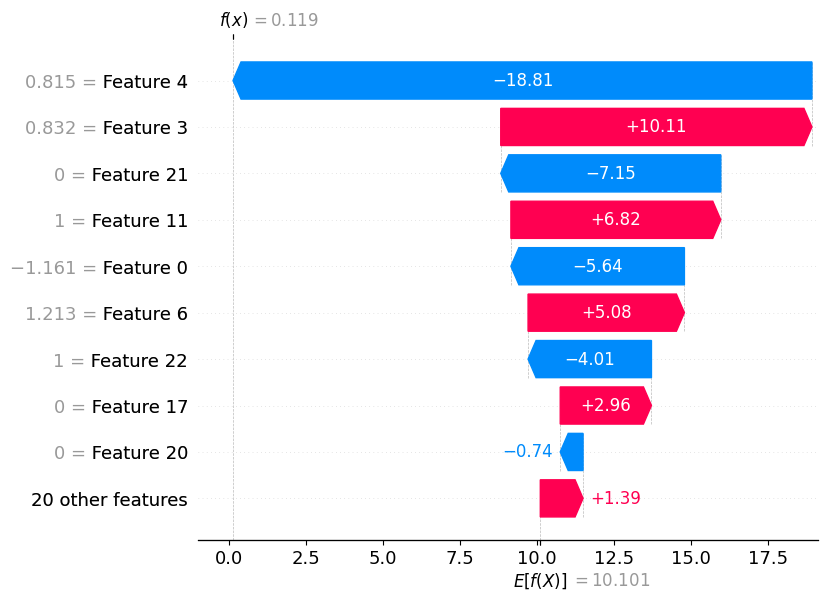

In [29]:
# Select an observation from the test set
index = 10  # Change this index to select different observations
single_observation = X_test.iloc[[index]]

# Preprocess the observation before explaining
preprocessed_observation = best_model.named_steps['preprocessing'].transform(single_observation)

# Calculate SHAP values for the selected observation
shap_values_single = explainer(preprocessed_observation)

# Plot the SHAP values for the selected observation
shap.waterfall_plot(shap_values_single[0])


Conclusions
Which Features to Remove: Based on SHAP feature importance, you would remove features with low or near-zero contributions to reduce model complexity.
Testing Feature Removal: By comparing RMSE before and after removing features, you can decide whether removing features actually enhances or maintains performance. If the reduced model's RMSE is comparable to or better than the original model, then removing those features is beneficial.

## Criteria

The [rubric](./assignment_3_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.